# Загрузка библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from tqdm.auto import tqdm
import warnings

from grokking_model import GrokkingTransformer
from grokking_utils import get_modular_addition_data, get_weight_norm, plot_omnigrok_replication

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float64)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Using cuda:0


# Генерация и предобработка данных

In [2]:
P = 113
FRACTION = 0.3
MAX_STEPS = 20000

X_train, Y_train, X_test, Y_test, num_total = get_modular_addition_data(
    p=P, fraction=FRACTION, seed=42, device=device
)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 3830 | Test size: 8939


# Архитектура модели

In [3]:
model = GrokkingTransformer(d_vocab=P + 1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss()

logs = {'step': [], 'train_loss': [], 'test_loss': [], 'train_acc':[], 'test_acc': [], 'weight_norm':[]}

# Обучение

In [4]:

print("\nStarting Omnigrok Training...")
loop = tqdm(range(1, MAX_STEPS + 1))

for step in loop:
    model.train()
    optimizer.zero_grad()

    logits_train = model(X_train)
    loss_train = criterion(logits_train, Y_train)

    with torch.no_grad():
        model.eval()
        logits_test = model(X_test)
        loss_test = criterion(logits_test, Y_test)

        acc_train = (logits_train.argmax(dim=1) == Y_train).float().mean().item()
        acc_test = (logits_test.argmax(dim=1) == Y_test).float().mean().item()
        w_norm = get_weight_norm(model)

        logs['step'].append(step)
        logs['train_loss'].append(loss_train.item())
        logs['test_loss'].append(loss_test.item())
        logs['train_acc'].append(acc_train)
        logs['test_acc'].append(acc_test)
        logs['weight_norm'].append(w_norm)

        if step % 500 == 0:
            loop.set_postfix(tr_acc=f"{acc_train:.2f}", te_acc=f"{acc_test:.2f}", norm=f"{w_norm:.1f}")

    loss_train.backward()
    optimizer.step()


Starting Omnigrok Training...


  0%|          | 0/20000 [00:00<?, ?it/s]

# Итоговые графики

Logs saved to 'omnigrok_official_logs.csv'


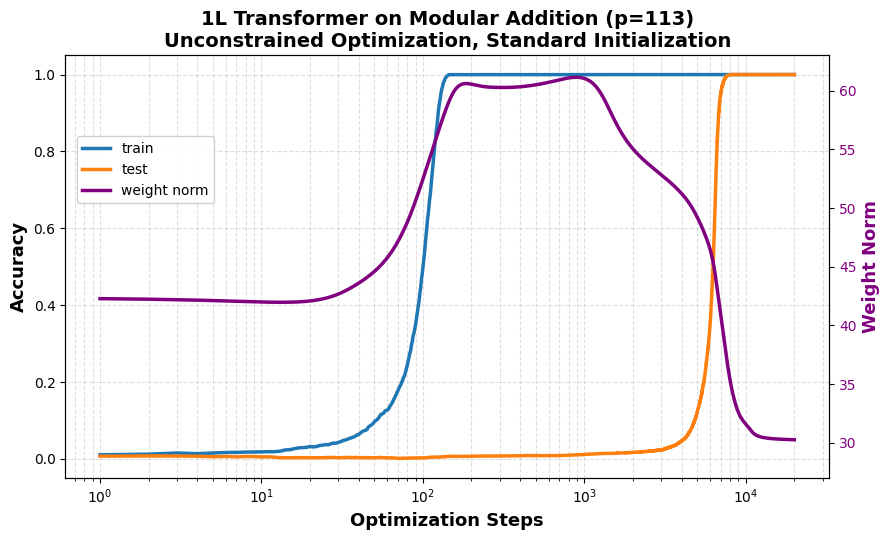

In [5]:
df_logs = pd.DataFrame(logs)
df_logs.to_csv('omnigrok_official_logs.csv', index=False)
print("Logs saved to 'omnigrok_official_logs.csv'")

plot_omnigrok_replication(df_logs, p=P, save_path='omnigrok_official_replication.pdf')